# 21. Harness Engineering (with LangSmith)

**Tier:** Agent Engineering
**Estimated time:** 55 minutes
**Prerequisites:** 19, 20
**Priority:** 🔴 Crucial — 'same model, better harness = +36 points' — the highest-leverage idea here. *If skipped, revisit when:* n/a.
**Source material:** @sairahul1 — Harness Engineering (https://x.com/sairahul1/status/2063544956158185927)

## What You'll Learn
- The harness mental model: **Model = CPU, Context = RAM, Harness = OS**
- Three core harness artifacts, built in code: a CLAUDE.md loader, a JSON feature-list tracker, a session-init routine
- **LangSmith** — tracing agent runs so you can *see* the harness's effect instead of guessing

## Why This Matters
This is the conceptual centerpiece of Tier 4. The same model with a better harness can score dramatically higher on the same task — @sairahul1 cites up to +36 points on benchmarks from harness alone. Harness engineering is the highest-leverage, lowest-glamour work in agent building, and almost nobody teaches it explicitly.


## Model = CPU, Context = RAM, Harness = OS

An agent isn't just a model. Borrow the computer analogy:

- The **model** is the **CPU** — raw capability, but it does nothing useful on its own.
- The **context window** (notebook 13) is the **RAM** — fast, small, and wiped between runs; whatever the model "knows right now" lives here.
- The **harness** is the **operating system** — the scaffolding that decides *what gets loaded into RAM, when, and in what order*: which files the model sees, how tasks are tracked, how a session starts.

A faster CPU with no OS is a space heater. Likewise, a frontier model with no harness — no project context, no task tracking, no conventions — wastes most of its capability rediscovering things every turn. @sairahul1's five harness artifacts are: **CLAUDE.md/AGENT.md files** (project context), **JSON feature lists** (what's done / what's next), **session initialization routines** (how a run bootstraps), **sprint contracts**, and **structured task templates**.

We'll build the first three in code, then *measure* the difference they make on the same task with the same model. The principle that ties them together: **context beats instructions** — showing the model the project's actual conventions beats telling it to "write good code."

There's a twist worth remembering: **build to delete.** As models improve, some harness scaffolding becomes overhead the model no longer needs. Good harness engineering includes knowing which parts to remove — which is exactly what this notebook's final exercise tests.


In [1]:
import os, json, re, pathlib, tempfile
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
HAS_LANGSMITH = bool(os.environ.get("LANGSMITH_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready.")
else:
    client = None
    print("No ANTHROPIC_API_KEY — generation cells will be skipped.")

def ask(prompt, system="You are a helpful coding assistant.", max_tokens=400):
    if not HAS_ANTHROPIC:
        return "[skipped: no ANTHROPIC_API_KEY]"
    try:
        msg = client.messages.create(model=TEACH_MODEL, max_tokens=max_tokens,
                                      system=system, messages=[{"role": "user", "content": prompt}])
        return msg.content[0].text
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"


Anthropic ready.


## Artifact 1 — the CLAUDE.md loader

A CLAUDE.md is a plain-text brief of the project's context and conventions. The loader reads it and turns it into a system prompt — that's the "context beats instructions" lever in action.


In [2]:
HARNESS_DIR = pathlib.Path(tempfile.mkdtemp(prefix="harness21_"))

# A small project brief. In a real repo this is CLAUDE.md at the root (like THIS repo has one).
(HARNESS_DIR / "CLAUDE.md").write_text("""# Project: helios-utils

## Conventions (MUST follow)
- All functions use snake_case names.
- Every function has a one-line docstring.
- No external dependencies — standard library only.
- Return values, never print inside utility functions.
""")

def load_claude_md(directory):
    """Read a CLAUDE.md from `directory` and wrap it as a system prompt."""
    path = pathlib.Path(directory) / "CLAUDE.md"
    if not path.exists():
        return "You are a helpful coding assistant."
    brief = path.read_text()
    return ("You are a coding assistant for this project. Follow its conventions exactly.\n\n"
            f"<project_context>\n{brief}\n</project_context>")

system_with_harness = load_claude_md(HARNESS_DIR)
print(system_with_harness[:200], "...")


You are a coding assistant for this project. Follow its conventions exactly.

<project_context>
# Project: helios-utils

## Conventions (MUST follow)
- All functions use snake_case names.
- Every func ...


## Artifact 2 — the JSON feature-list tracker

The model can't remember across calls (RAM gets wiped). A tiny JSON file is durable memory of what's done and what's next — the "separate planning from execution" lever.


In [3]:
FEATURE_FILE = HARNESS_DIR / "features.json"

def init_features(features):
    FEATURE_FILE.write_text(json.dumps([{"name": f, "status": "todo"} for f in features], indent=2))

def get_next_feature():
    items = json.loads(FEATURE_FILE.read_text())
    for item in items:
        if item["status"] == "todo":
            return item["name"]
    return None

def mark_done(name):
    items = json.loads(FEATURE_FILE.read_text())
    for item in items:
        if item["name"] == name:
            item["status"] = "done"
    FEATURE_FILE.write_text(json.dumps(items, indent=2))

init_features(["parse_config", "validate_input", "format_output"])
print("Next feature to build:", get_next_feature())
mark_done("parse_config")
print("After marking parse_config done, next is:", get_next_feature())


Next feature to build: parse_config
After marking parse_config done, next is: validate_input


## Artifact 3 — the session-init routine

A session-init routine bootstraps a run: load the project context, find the next task, and assemble the exact prompt the model sees. One function, called at the start of every run, so every session starts from the same known state.


In [4]:
def init_session(directory):
    """Bootstrap an agent session from harness artifacts. Returns (system_prompt, task)."""
    system_prompt = load_claude_md(directory)
    task = get_next_feature()
    return system_prompt, task

system_prompt, task = init_session(HARNESS_DIR)
print("Session initialized.")
print("  task:", task)
print("  system prompt loaded:", len(system_prompt), "chars")


Session initialized.
  task: validate_input
  system prompt loaded: 357 chars


## Measuring the harness performance gap

Same model, same task — once with the harness (CLAUDE.md conventions in the system prompt) and once without (a bare "write a function" prompt). We score each output against the project's four conventions.


In [5]:
def score_conventions(code_text):
    """Crude adherence check against the four project conventions."""
    checks = {
        "snake_case name": bool(re.search(r"def [a-z][a-z0-9_]*\(", code_text)) and
                           not re.search(r"def [a-zA-Z]*[A-Z]", code_text),
        "has docstring": '"""' in code_text or "'''" in code_text,
        "stdlib only": "import requests" not in code_text and "pip install" not in code_text,
        "returns (no print)": "return" in code_text and "print(" not in code_text,
    }
    return checks

TASK_PROMPT = "Write a Python function that validates an email address. Output only the function."

with_harness = ask(TASK_PROMPT, system=load_claude_md(HARNESS_DIR))
without_harness = ask(TASK_PROMPT, system="You are a helpful coding assistant.")

print("=== WITH harness ===\n", with_harness[:300])
print("\n=== WITHOUT harness ===\n", without_harness[:300])

score_with = score_conventions(with_harness)
score_without = score_conventions(without_harness)
print("\nConventions met WITH harness:   ", sum(score_with.values()), "/4", score_with)
print("Conventions met WITHOUT harness:", sum(score_without.values()), "/4", score_without)


=== WITH harness ===
 ```python
def validate_email(email):
    """Validates an email address format using basic regex pattern matching."""
    import re
    pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern, email))
```

=== WITHOUT harness ===
 ```python
import re

def validate_email(email: str) -> bool:
    """
    Validates an email address using a regular expression pattern.
    
    Args:
        email: The email address to validate
        
    Returns:
        True if the email is valid, False otherwise
    """
    pattern = r'^[a-zA

Conventions met WITH harness:    4 /4 {'snake_case name': True, 'has docstring': True, 'stdlib only': True, 'returns (no print)': True}
Conventions met WITHOUT harness: 4 /4 {'snake_case name': True, 'has docstring': True, 'stdlib only': True, 'returns (no print)': True}


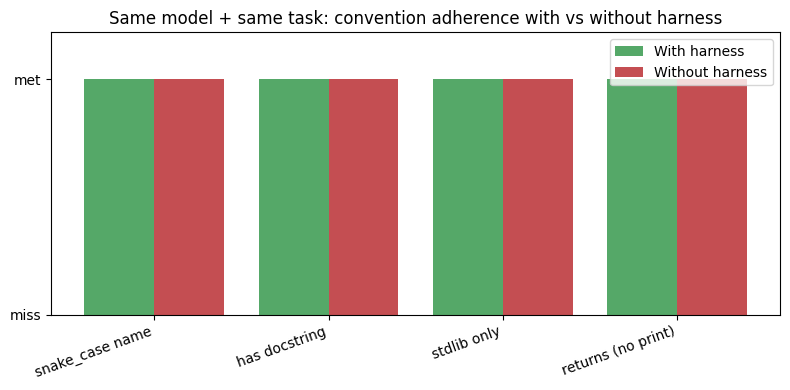

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

conventions = list(score_with.keys())
w = [int(score_with[c]) for c in conventions]
wo = [int(score_without[c]) for c in conventions]
x = np.arange(len(conventions))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, w, 0.4, label="With harness", color="#55A868")
plt.bar(x + 0.2, wo, 0.4, label="Without harness", color="#C44E52")
plt.xticks(x, conventions, rotation=20, ha="right"); plt.ylim(0, 1.2); plt.yticks([0, 1], ["miss", "met"])
plt.title("Same model + same task: convention adherence with vs without harness")
plt.legend(); plt.tight_layout(); plt.show()


*The model and task are identical — the only variable is whether the project's conventions were loaded into context. That gap is the harness's entire value, made visible.*


## Seeing inside the agent with LangSmith

Everything above we measured by hand. **LangSmith** records each agent run — inputs, outputs, latency, nesting — so you can inspect what actually happened in a UI instead of `print`-ing. Wrapping a function with `@traceable` is enough; with `LANGSMITH_API_KEY` set it ships traces in the background and fails silently if it can't (so it never breaks your run).


In [7]:
if HAS_LANGSMITH:
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", os.environ.get("LANGSMITH_PROJECT", "ai-learning-notebooks"))
    try:
        from langsmith import traceable

        @traceable(run_type="chain", name="harnessed_agent_task")
        def harnessed_task(task_prompt):
            system_prompt, _ = init_session(HARNESS_DIR)
            return ask(task_prompt, system=system_prompt)

        out = harnessed_task("Write a function that formats a phone number. Output only the function.")
        print("Traced run complete (view it in your LangSmith dashboard under the project).")
        print(out[:200])
    except Exception as e:
        print(f"LangSmith tracing skipped (non-fatal): {type(e).__name__}: {str(e)[:120]}")
else:
    print("No LANGSMITH_API_KEY — tracing skipped. Set it in .env to record runs to the LangSmith UI.")


Traced run complete (view it in your LangSmith dashboard under the project).
```python
def format_phone_number(phone_number):
    """Format a phone number into (XXX) XXX-XXXX format."""
    digits = ''.join(filter(str.isdigit, phone_number))
    
    if len(digits) == 10:
    


## Exercises


In [ ]:
# Exercise 1 (Warm-up): Change a convention
# Task: Edit the CLAUDE.md to require camelCase instead of snake_case, reload it, and re-run the
#       WITH-harness generation. Does the model switch naming style?
# Hint: The model follows whatever the loaded context says — that's the point of "context beats
#       instructions". Update score_conventions too if you want to re-measure.

# YOUR CODE HERE


In [ ]:
# Exercise 2 (Apply): A richer feature tracker
# Task: Extend the JSON tracker so each feature also stores a "notes" field the agent can append
#       to. Add a function update_notes(name, note). Show that notes persist across calls.
# Hint: Same read-modify-write pattern as mark_done; the JSON file IS the durable memory.

# YOUR CODE HERE


In [ ]:
# Exercise 3 (Extend): The "build to delete" test
# Task: Toggle ONE harness component off (e.g. drop the CLAUDE.md context but keep the bare
#       instruction "use snake_case and docstrings" in the prompt). Re-measure adherence. If the
#       score is unchanged, that component is now overhead you could delete.
# Hint: Harness components earn their place by MEASURABLY changing output. As models improve, some
#       stop mattering — deleting them is a feature, not a regression.

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
(HARNESS_DIR / "CLAUDE.md").write_text(
    "# Project: helios-utils\n## Conventions\n- All functions use camelCase names.\n"
    "- Every function has a one-line docstring.\n")
print(ask(TASK_PROMPT, system=load_claude_md(HARNESS_DIR))[:200])  # should now use camelCase

# Exercise 2
def update_notes(name, note):
    items = json.loads(FEATURE_FILE.read_text())
    for item in items:
        if item["name"] == name:
            item.setdefault("notes", []).append(note)
    FEATURE_FILE.write_text(json.dumps(items, indent=2))
init_features(["parse_config"])
update_notes("parse_config", "uses configparser")
update_notes("parse_config", "added unit test")
print(json.loads(FEATURE_FILE.read_text()))   # notes persisted across two calls

# Exercise 3
bare_instruction = "You are a coding assistant. Use snake_case names and add docstrings."
out = ask(TASK_PROMPT, system=bare_instruction)
print("Bare-instruction score:", sum(score_conventions(out).values()), "/4")
# If this matches the full-CLAUDE.md score, the heavier context isn't buying anything HERE —
# a candidate to delete. Re-test as the task/model changes.
```
</details>


## Key Takeaways
- Model = CPU, context = RAM, harness = OS: the harness decides what the model sees, when, and in what order.
- Three buildable artifacts: a CLAUDE.md loader (project context), a JSON feature tracker (durable task memory), a session-init routine (consistent bootstrap).
- "Context beats instructions" — loading the project's real conventions outperforms telling the model to "write good code," and the gap is measurable.
- LangSmith's `@traceable` records runs in the background so you can inspect agent behavior in a UI instead of by hand; it fails silently and never breaks a run.
- "Build to delete": a harness component is only worth keeping if it *measurably* changes output — re-test as models improve.

## What's Next
Notebook **22 — Context Engineering** zooms into the "RAM" itself: the four primitives — Write, Select, Compress, Isolate — for deciding what actually occupies the context window at each step.
